In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("WineQT.csv")

In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


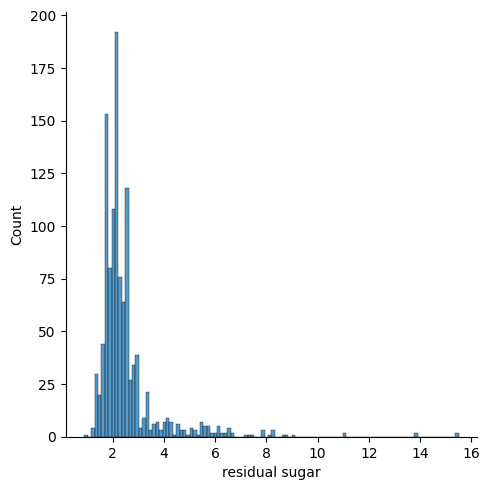

In [5]:
sns.displot(df['residual sugar'])

<Axes: xlabel='residual sugar'>

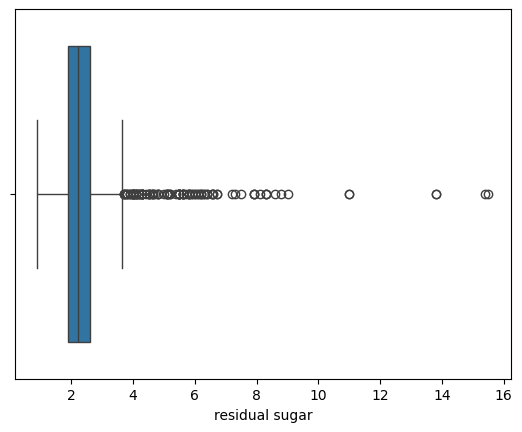

In [6]:
sns.boxplot(x=df['residual sugar'])

In [7]:
# # z-score Method

#finding the limits

upper_limit = df['residual sugar'].mean() + 3*df['residual sugar'].std()
lower_limit = df['residual sugar'].mean() - 3*df['residual sugar'].std()
print('Upper Limit :',upper_limit)
print('Lower Limit : ',lower_limit)

Upper Limit : 6.599904631019168
Lower Limit :  -1.5356001690769112


In [9]:
# # #finding the outliers

print(df.loc[(df['residual sugar'] > upper_limit) | (df['residual sugar'] < lower_limit)])
file1 = df.loc[(df['residual sugar'] > upper_limit) | (df['residual sugar'] < lower_limit)]
file1.to_csv("outliers_in_Z_square_winedataset.csv",index= False)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
114             7.4             0.600         0.26             7.3      0.070   
115             7.3             0.590         0.26             7.2      0.070   
230            10.0             0.490         0.20            11.0      0.071   
231            10.0             0.490         0.20            11.0      0.071   
275             6.6             0.735         0.02             7.9      0.122   
278             6.6             0.735         0.02             7.9      0.122   
287             9.9             0.400         0.53             6.7      0.097   
289             8.6             0.725         0.24             6.6      0.117   
339            10.6             0.280         0.39            15.5      0.069   
348             6.5             0.390         0.23             8.3      0.051   
424             8.9             0.595         0.41             7.9      0.086   
460             6.7         

In [10]:
new_df = df.loc[(df['residual sugar'] < upper_limit) & (df['residual sugar'] > lower_limit)]
new_df.to_csv("outliers_removed_winedatset.csv",index= False)
print('Before removing Outliers : ',len(df))
print('After removing outliers : ',len(new_df))
print('outliers : ',len(df)-len(new_df))

Before removing Outliers :  1143
After removing outliers :  1120
outliers :  23


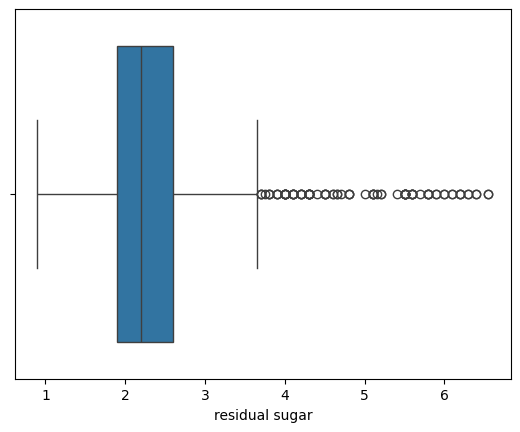

In [11]:
sns.boxplot(x=new_df['residual sugar'])
plt.show()

In [12]:
q1 = df['residual sugar'].quantile(0.25)
q3 = df['residual sugar'].quantile(0.75)

IQR = q3-q1
print(IQR,q1,q3)

lower = q1-1.5*IQR
upper = q3+1.5*IQR
print(lower,upper)

0.7000000000000002 1.9 2.6
0.8499999999999996 3.6500000000000004


<Axes: xlabel='residual sugar'>

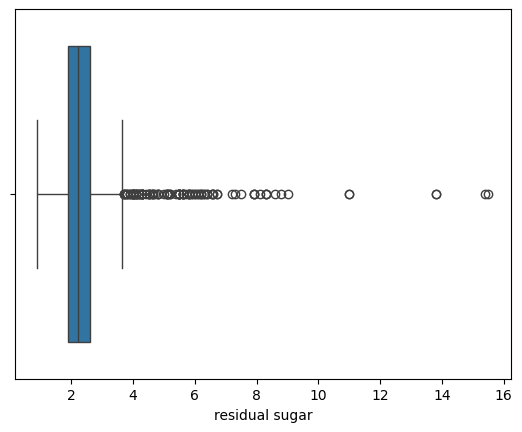

In [13]:
sns.boxplot(x = df['residual sugar'])

In [14]:
print(df.loc[(df['residual sugar'] > upper_limit) | (df['residual sugar'] < lower_limit)])
new_df = df.loc[(df['residual sugar'] < upper_limit) & (df['residual sugar'] > lower_limit)]
print('Before removing Outliers : ',len(df))
print('After removing outliers : ',len(new_df))
print('outliers : ',len(df)-len(new_df))

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
114             7.4             0.600         0.26             7.3      0.070   
115             7.3             0.590         0.26             7.2      0.070   
230            10.0             0.490         0.20            11.0      0.071   
231            10.0             0.490         0.20            11.0      0.071   
275             6.6             0.735         0.02             7.9      0.122   
278             6.6             0.735         0.02             7.9      0.122   
287             9.9             0.400         0.53             6.7      0.097   
289             8.6             0.725         0.24             6.6      0.117   
339            10.6             0.280         0.39            15.5      0.069   
348             6.5             0.390         0.23             8.3      0.051   
424             8.9             0.595         0.41             7.9      0.086   
460             6.7         

<Axes: xlabel='residual sugar'>

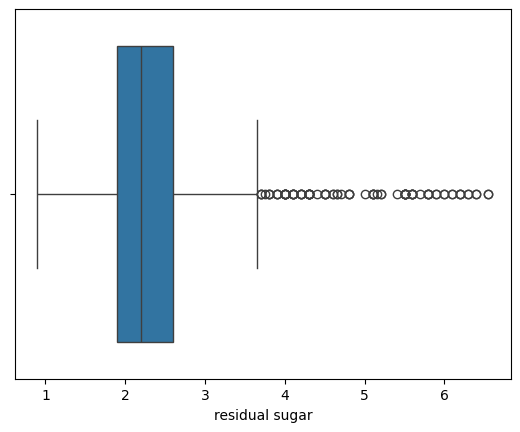

In [15]:
sns.boxplot(x = new_df['residual sugar'])

In [16]:
# #capping

new_df = df.copy()
new_df.loc[(new_df['residual sugar'] > upper_limit),'residual sugar'] = upper_limit
new_df.loc[(new_df['residual sugar'] < lower_limit),'residual sugar'] = lower_limit

<Axes: xlabel='residual sugar'>

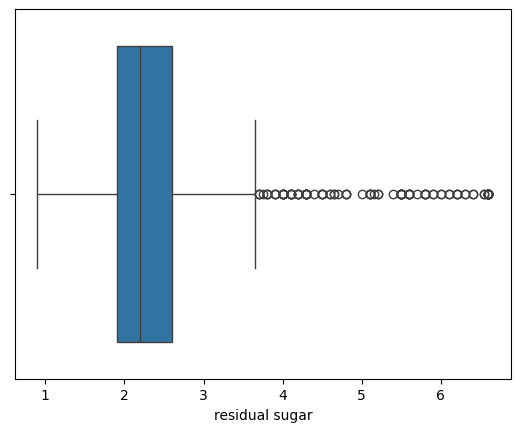

In [17]:
sns.boxplot(x = new_df['residual sugar'])

In [18]:
df = pd.read_csv("creditcard.csv")
df_num = df[['Amount']]

In [20]:
df.shape

(284807, 31)

In [21]:
X = df.drop('Class', axis=1)

iso = IsolationForest(contamination=0.002, random_state=42)
df['anomaly'] = iso.fit_predict(X)

In [22]:
# Keep only normal points
df_iso_cleaned = df[df['anomaly'] == 1]

In [23]:
# Drop anomaly column
df_iso_cleaned = df_iso_cleaned.drop('anomaly', axis=1)

In [24]:
print("After Isolation Forest removal:", df_iso_cleaned.shape)

print('Before removing Outliers : ',len(df))
print('After removing outliers : ',len(df_iso_cleaned))
print('outliers : ',len(df)-len(df_iso_cleaned))

After Isolation Forest removal: (284237, 31)
Before removing Outliers :  284807
After removing outliers :  284237
outliers :  570
